In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [6]:
from src import utils 
from src import meshharm
from src.fatemarkers import FateMarkers

In [7]:
path = 'Data/20250714/fractal_output/'

timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
        'day1p5': 'r0.zarr',
        'day2':'r0.zarr',
        'day2p5':'r0.zarr',
        'day3':'r0.zarr',
        'day3p5':'r0.zarr',
        'day4':'r0.zarr',
        'day4p5':'r0.zarr',
        'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

rounds = {
    'day1p5': ['0_fused_zillum'],
    'day2': ['0_fused_zillum'],
    'day2p5': ['0_fused_zillum'],
    'day3': ['0_fused_zillum'],
    'day3p5': ['0_fused_zillum'],
    'day4': ['0_fused_zillum'],
    'day4p5': ['0_fused_zillum'],
    'day4p5-more': ['0_fused_zillum'],
}
times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [28]:
def load(save_path, ts): 
    m = FateMarkers()
    m.load_results(save_path)
    frac_diff = m.compute_recon_quality()
    coeffs_hks = m.compute_hks_for_new_times(new_ts=ts)
    spectrums = np.sqrt(m.compute_spectrum(coeffs_hks))/m.mass_matrix.diagonal().sum() 
    return spectrums, frac_diff

In [30]:
spectrums = [] 
times = [] 
fracs = [] 
ids = [] 

ts = np.exp(2*np.linspace(0, np.log(10), 100))



for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]

        file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(file_path + 'good_labels.npy').astype('int')
        print(file_path) 
        for label in tqdm(labels[::10]):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                coor_spectrum, frac = load(save_path, ts=ts)
                spectrums.append(coor_spectrum)
                times.append(timepoint[3:6])
                fracs.append(frac)
                ids.append(f"{timepoint}_{well_name}_{label}") 

Data/20250714/fractal_output/day1p5/r0.zarr/A/01/0_fused_zillum/


100%|██████████| 12/12 [00:04<00:00,  2.83it/s]


Data/20250714/fractal_output/day1p5/r0.zarr/A/02/0_fused_zillum/


100%|██████████| 6/6 [00:02<00:00,  2.93it/s]


Data/20250714/fractal_output/day1p5/r0.zarr/A/03/0_fused_zillum/


...

100%|██████████| 10/10 [00:02<00:00,  4.86it/s]


Data/20250714/fractal_output/day4p5-more/r0.zarr/C/05/0_fused_zillum/


100%|██████████| 11/11 [00:02<00:00,  4.99it/s]


Data/20250714/fractal_output/day4p5-more/r0.zarr/C/06/0_fused_zillum/


100%|██████████| 14/14 [00:02<00:00,  4.93it/s]


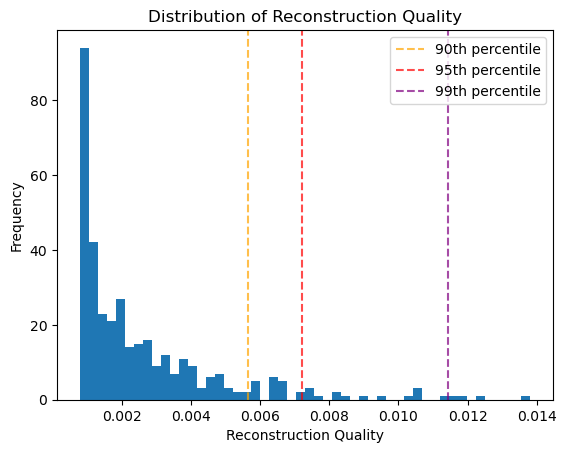

In [31]:
plt.hist(fracs, bins=50)
plt.axvline(np.percentile(fracs, 90), color='orange', linestyle='--', alpha=0.7, label='90th percentile')
plt.axvline(np.percentile(fracs, 95), color='red', linestyle='--', alpha=0.7, label='95th percentile')
plt.axvline(np.percentile(fracs, 99), color='purple', linestyle='--', alpha=0.7, label='99th percentile')
plt.legend()
plt.xlabel('Reconstruction Quality')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Quality')
plt.show()

In [32]:
threshold = np.percentile(fracs, 95)
recon_mask = np.array(fracs) < threshold

filtered_times = np.array(times)[recon_mask]
filtered_spectrums = np.array(spectrums)[recon_mask]
filtered_ids = np.array(ids)[recon_mask]

In [35]:
print(filtered_spectrums.shape) 

(341, 15, 100)


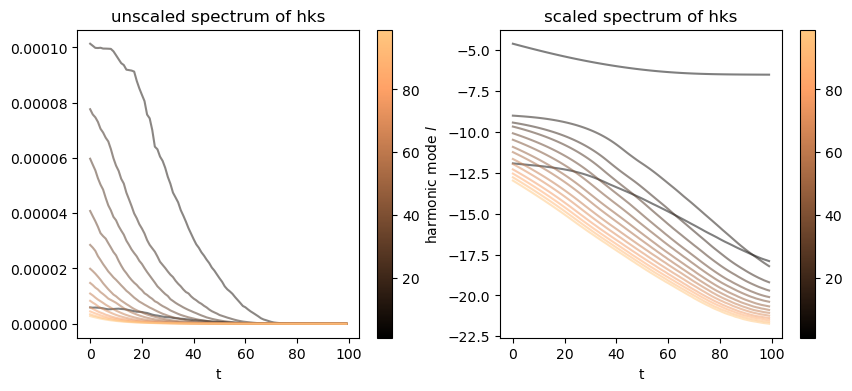

In [38]:
from sklearn.preprocessing import Normalizer

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)    

rescaled_spectrums = np.zeros_like(filtered_spectrums)
# Get the copper colormap
copper_cmap = plt.get_cmap('copper')
n_components = filtered_spectrums.shape[1] - 1
scaler = Normalizer() 

for i in range(0, filtered_spectrums.shape[1]): 
    color = copper_cmap((i-1) / (n_components-1))  # Normalize i to [0,1] range
    if i > 0: 
        axes[0].plot(np.median(filtered_spectrums[:, i, :], axis=0), color=color, alpha=0.5)
    rescaled_spectrums[:, i, :] = np.log(filtered_spectrums[:, i, :])
    axes[1].plot(np.mean(rescaled_spectrums[:, i, :], axis=0), color=color, alpha=0.5)

axes[0].set_xlabel('t')
axes[1].set_xlabel('t')
axes[0].set_title('unscaled spectrum of hks')
axes[1].set_title('scaled spectrum of hks')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=copper_cmap, norm=plt.Normalize(vmin=1, vmax=filtered_spectrums.shape[-1]-1))
cbar = plt.colorbar(sm, ax=axes[1])
cbar = plt.colorbar(sm, ax=axes[0])
cbar.set_label(r'harmonic mode $l$')

plt.show() 

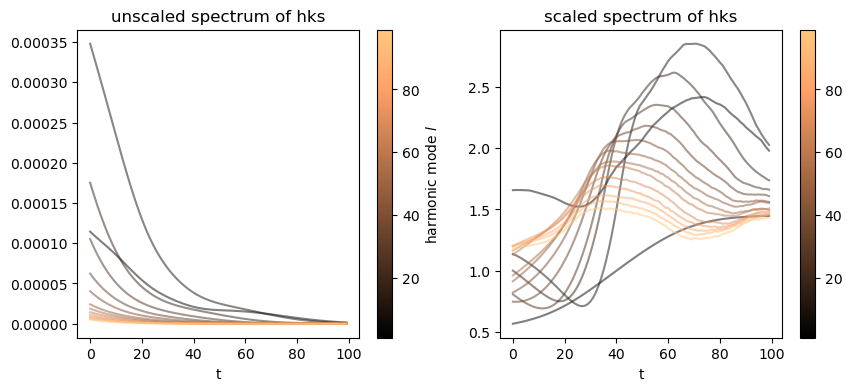

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)    
# Get the copper colormap
copper_cmap = plt.get_cmap('copper')
n_components = filtered_spectrums.shape[1] - 1

for i in range(0, filtered_spectrums.shape[1]): 
    color = copper_cmap((i-1) / (n_components-1))  # Normalize i to [0,1] range
    if i > 0: 
        axes[0].plot(np.std(filtered_spectrums[:, i, :], axis=0), color=color, alpha=0.5)

    axes[1].plot(np.std(rescaled_spectrums[:, i, :], axis=0), color=color, alpha=0.5)

axes[0].set_xlabel('t')
axes[1].set_xlabel('t')
axes[0].set_title('unscaled spectrum of hks')
axes[1].set_title('scaled spectrum of hks')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=copper_cmap, norm=plt.Normalize(vmin=1, vmax=filtered_spectrums.shape[-1]-1))
cbar = plt.colorbar(sm, ax=axes[1])
cbar = plt.colorbar(sm, ax=axes[0])
cbar.set_label(r'harmonic mode $l$')

plt.show() 

In [133]:

t_space_vectors = rescaled_spectrums.reshape(-1, rescaled_spectrums.shape[-1]) 

scaler = StandardScaler()
t_space_vectors = scaler.fit_transform(t_space_vectors)
print(t_space_vectors.shape) 

(5115, 100)


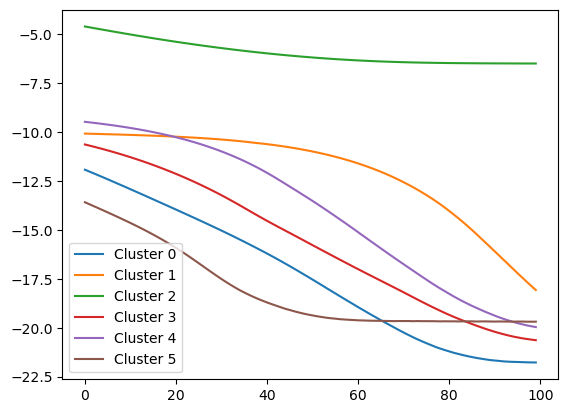

In [139]:
from sklearn.cluster import KMeans

n_clusters = 6

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(t_space_vectors)
vocab = kmeans.cluster_centers_ 
vocab_og = scaler.inverse_transform(vocab)

for i, v in enumerate(vocab_og): 
    plt.plot(v, label=f'Cluster {i}')
plt.legend() 
plt.show() 

In [140]:
cluster_id = kmeans.predict(t_space_vectors)

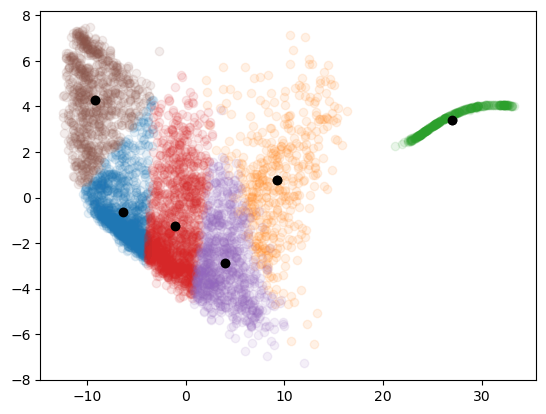

In [141]:
pca = PCA(n_components=2)
pca.fit(t_space_vectors) 
t_space_pcs = pca.transform(t_space_vectors)
v_pcs = pca.transform(vocab)

plt.plot(v_pcs[:, 0], v_pcs[:, 1], 'ko')
for id in range(n_clusters): 
    mask = (cluster_id == id)
    plt.plot(t_space_pcs[mask, 0], t_space_pcs[mask, 1], 'o', alpha=0.1)
plt.plot(v_pcs[:, 0], v_pcs[:, 1], 'ko')
plt.show() 

In [142]:
dist = kmeans.transform(t_space_vectors)
cluster_id = np.argmin(dist, axis=1)

# compute typical cluster size 
sigma = np.mean(dist[:, cluster_id])
encoding = np.exp(-dist**2/(2*sigma**2))
print(encoding.shape)

(5115, 6)


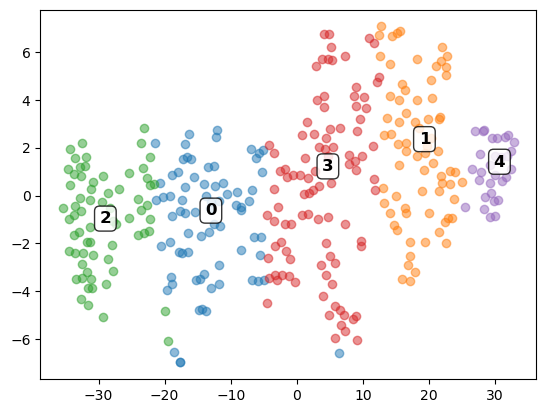

In [ ]:
encoding_reshaped = encoding.reshape(rescaled_spectrums.shape[0], -1)

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(encoding_reshaped)

dist = kmeans.transform(encoding_reshaped)
cluster_id = np.argmin(dist, axis=1)


from sklearn.manifold import MDS, TSNE 
mds = TSNE(n_components=2, random_state=42, perplexity=30)

to_fit = np.concatenate((encoding_reshaped, kmeans.cluster_centers_), axis=0)
mds.fit(to_fit)
reduced_dim_rep = mds.fit_transform(to_fit)

spectrum_pcs = reduced_dim_rep[:encoding_reshaped.shape[0], :]
cluster_pcs = reduced_dim_rep[encoding_reshaped.shape[0]:, :]

# import umap
# reducer = umap.UMAP(n_components=2, random_state=42)
# spectrum_pcs = reducer.fit_transform(encoding_reshaped) 
# cluster_pcs = reducer.transform(kmeans.cluster_centers_)



for id in range(n_clusters): 
    mask = (cluster_id == id)
    plt.plot(spectrum_pcs[mask, 0], spectrum_pcs[mask, 1], 'o', alpha=0.5)
for i in range(len(cluster_pcs)): 
    plt.text(cluster_pcs[i, 0], cluster_pcs[i, 1], 
             str(i), fontsize=12, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black', alpha=0.8))
plt.show()

['1p5' '2' '2p5' '3' '3p5' '4' '4p5']


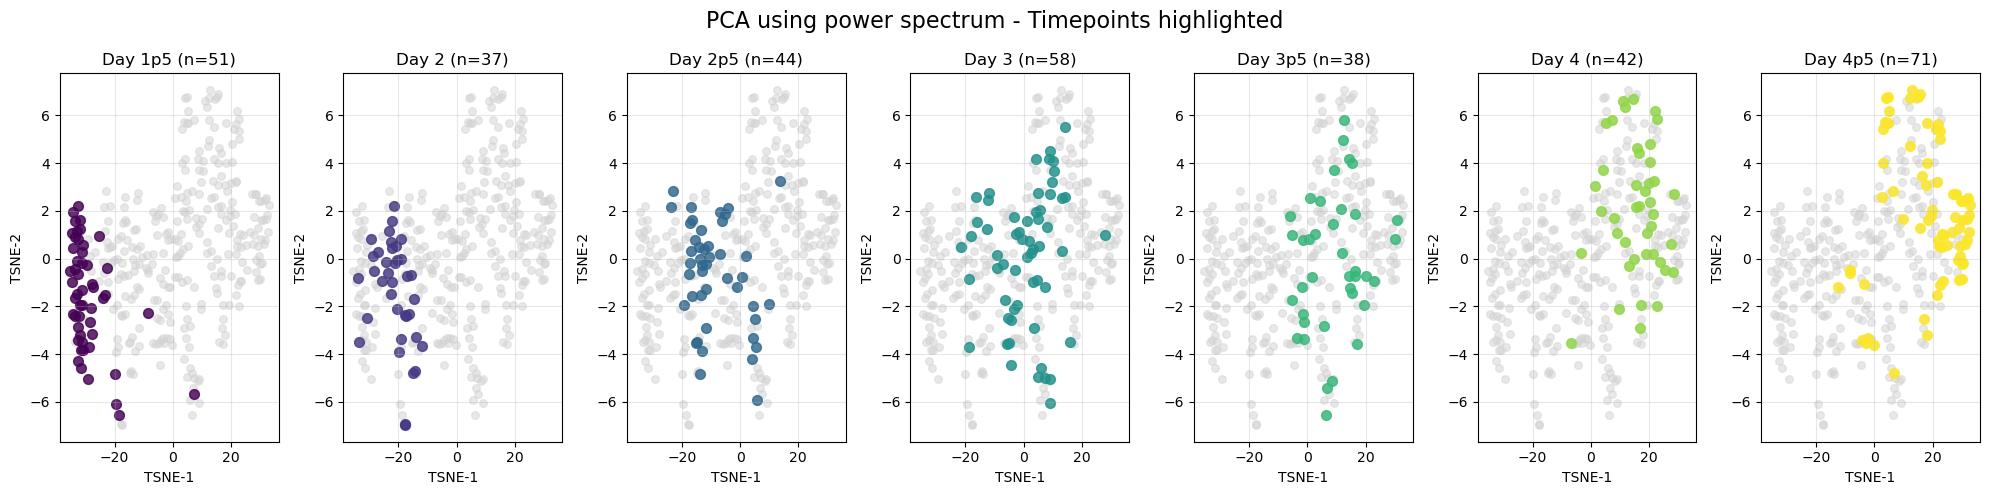

In [144]:
# Create subplots for each timepoint - spectrum PCA
unique_times = np.unique(times)

print(unique_times)
# Use a continuous colormap that represents time progression
cmap = plt.cm.viridis  # You can also try 'plasma', 'inferno', 'magma', 'cool', 'warm'
colors = [cmap(i / (len(unique_times) - 1)) for i in range(len(unique_times))]

fig, axes = plt.subplots(1, 7, figsize=(20, 5))

for i, time in enumerate(unique_times):
    ax = axes[i]
    
    # Plot all points in light gray
    ax.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], 
              c='lightgray', alpha=0.5, s=30)
    
    # Highlight current timepoint with color from continuous map
    times_mask = (filtered_times == time)
    ax.scatter(spectrum_pcs[:, 0][times_mask], spectrum_pcs[:, 1][times_mask], 
              c=[colors[i]], alpha=0.8, s=50, label=f'Day {time}')
    
    ax.set_xlabel('TSNE-1')
    ax.set_ylabel('TSNE-2')
    ax.set_title(f'Day {time} (n={np.sum(times_mask)})')
    ax.grid(True, alpha=0.3)

plt.suptitle('PCA using power spectrum - Timepoints highlighted', fontsize=16)
plt.tight_layout()
plt.show()

In [145]:
dist = kmeans.transform(encoding_reshaped) 

# Find the closest point to each cluster center
cluster_center_ids = filtered_ids[np.argmin(dist, axis=0)[[2, 0, 3, 1, 4]]]

print(cluster_center_ids) 

['day2_A06_2' 'day2p5_A03_97' 'day3_A02_11' 'day3p5_B03_93'
 'day4p5-more_C05_146']


In [146]:
from meshplot import plot

for i, id in enumerate(cluster_center_ids): 
    timepoint, well_name, label = id.split('_')
    zarr_name = zarr_names[timepoint]
    round_name = rounds[timepoint][0]
    file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/fm_data/{label}"
    m = FateMarkers()
    m.load_results(file_path) 

    coeffs_hks = m.compute_hks_for_new_times(new_ts=[1, 25])
    hks = m.reconstruct_from_coeffs(coeffs_hks[:])
    
    # Create the meshplot visualization
    print(np.min(hks[:, -1]), np.max(hks[:, -1]))
    plot(m.v, m.f, c=hks[:, -1])

0.04453615 0.044539176


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.028587…

0.017976876 0.017977832


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0181944…

0.008644845 0.008744743


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0070472…

0.006396628 0.0069785444


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.056982…

0.0041806186 0.007892306


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.3875434…